---

### 🐣 0.1 RPC란 무엇인가? (Remote Procedure Call)
우리가 파이썬 코드 안에서 함수를 부를 때는 `add_numbers(1, 2)` 처럼 매우 당연하게 **로컬 컴퓨터 메모리 안에 있는 코드**를 실행(Call)합니다.
하지만 서비스가 커지면 다른 컴퓨터(서버)가 계산을 대신 해야 할 때가 있습니다. **RPC(원격 프로시저 호출)**는 "내 컴퓨터가 아닌 **수백 킬로미터 떨어져 있는 다른 서버 컴퓨터에 있는 함수**를, 마치 내 컴퓨터에 있는 함수를 부르듯이 똑같이 투명하게 호출하게 해주는 기술"입니다.
개발자 입장에서는 외부망으로 데이터를 보내기 위해 억지로 HTTP 형식(`POST /add`)으로 포장하는 번거로움 없이 직관적인 스크립트 기반 코딩이 가능합니다.

### 🐣 0.2 그렇다면 gRPC란 무엇인가?
**gRPC** (gRPC Remote Procedure Call)는 앞서 말한 전통적인 RPC라는 개념을, **구글(Google)**이 현대 클라우드 아키텍처에 맞게 완전히 새롭고 압도적으로 빠르게 쓸 수 있도록 재창조하여 오픈소스로 공개한 **"초고속 통신 프레임워크"**입니다. 
수많은 마이크로서비스(MSA) 서버 인스턴스들이 내부적으로 소통할 때, 데이터의 크기를 줄이고 제일 빠르게 소통할 수 있도록 하는 **"가장 최신의 표준 고속도로망"**이라고 이해하시면 됩니다. 단, 일반 노트북에서 쓰는 것은 아니고 주로 백엔드 서버끼리의 통신에 쓰입니다.

### 🐣 0.3 로드 밸런싱(Load Balancing)이란?
단어 그대로 **"Load(트래픽 부하)"**를 **"Balancing(균형 맞추기)"** 한다는 뜻입니다. 만약 유저가 10만 명 접속했을 때 웹 서버가 단 1대만 있다면 버티지 못하고 다운되어 버리겠죠.
그래서 회사는 1번부터 100번까지 100대의 서버 머신을 켜둡니다. 이때 10만 명의 유저가 아무렇게나 1번 서버로만 죄다 몰리지 않도록, 맨 앞에서 100대의 서버 상황을 보고 골고루 트래픽을 나눠주는 **'서버 앞단의 분산 교통경찰'** 장비를 로드 밸런서라고 부릅니다.

### 🐣 0.4 VPC란 무엇인가? (Virtual Private Cloud)
퍼블릭 클라우드 장비(AWS, GCP, Azure 등)는 전 세계 누구나 돈만 내면 들어와서 쓸 수 있는 거대한 쉐어하우스 바다입니다. 
하지만 이 바다 한가운데에 **'오직 우리 회사만의 네트워크 인프라 자원만 띄울 수 있도록 허가된, 자물쇠가 달린 사유지 울타리'**를 치고 분리된 공간을 만드는 기술이 VPC입니다. 
VPC가 없으면 남의 회사의 인프라 영역이나 해커의 스캔에 우리 서버가 무방비하게 얽힐 수 있습니다. 즉 클라우드 속에 "완전하게 독립된 나만의 가상 데이터 센터 본부 망을 짓는 것"을 뜻합니다.



---


## 1. 분산 환경의 통신 최적화: REST API의 한계와 gRPC 도입 배경


기초를 단단히 다졌으니, 이제 왜 현업에서 기존의 통신 방식(REST API)을 버리고 gRPC를 앞다투어 도입하는지 그 딥다이브 이론에 빠져봅시다.

### 1.1 기존 통신 - JSON 직렬화(Serialization) 오버헤드와 한계
현대 애플리케이션 통신 규약은 대부분 REST API와 JSON 텍스트 기반으로 이루어져 있습니다. 사람의 눈으로 데이터를 읽고 디버깅하기에는 뛰어납니다. 하지만 **수십~수백 MB 짜리 고차원 수치 배열(Tensor, 이미지 등) 데이터를 지속해서 주고받는 머신러닝 백엔드 환경에서는 치명적인 병목(Bottleneck)** 지점이 됩니다.

- **데이터 뻥튀기 오버헤드**: `3.141592`라는 부동소수점을 전송해 볼까요? 로컬 메모리상에서는 4바이트 크기에 불과하지만, 이를 JSON 통신용 포맷으로 텍스트화(직렬화)하면 `-`, `.`, 숫자 1개당 1바이트씩 텍스트로 인코딩되어 네트워크 대역폭(데이터 크기)이 엄청나게 부풀어 버립니다.
- **CPU 리소스 극한 낭비**: 수신한 서버 측은 도착한 긴 문자열 텍스트를 하나하나 분별해 다시 파이썬이나 C++ 내부 실수(Float) 구조 단위로 재조립 파싱(Parsing)해야 합니다. 이 작업에 엄청난 CPU 점유가 일어납니다.

### 1.2 Protocol Buffers (Protobuf) 매커니즘
구글 gRPC는 이 한계를 부수기 위해 JSON 문자열 대전환 과정을 아예 폐기하고, **이진수(Binary) 연속체**로 데이터를 압축 직렬화해버리는 방법을 채택했습니다. 이때 그 데이터의 뼈대를 어떻게 해석할지 `.proto`라는 파일 설계도(규격서)를 기준으로 삼습니다.

- 필드 이름조차 보내지 않고 **순서 태그(번호표)**만 전달합니다. 데이터 크기가 미친 듯이 압축됩니다.
- 서버와 클라이언트가 둘 다 동일한 설계도(코드북)를 미리 가지고 있으므로, "도착하자마자 1번칸의 값, 2번칸의 값을 기계적으로 바로바로 조립" 해버리는 형태여서 통신 속도와 해석 속도 체급이 다릅니다.

### 1.3 차세대 도로망: HTTP/2
gRPC는 통신 경로 자체를 HTTP/1.1에서 차세대 규격인 **HTTP/2**로 갈아엎었습니다.
- **멀티플렉싱(Multiplexing)**: 이전엔 하나의 파이프라인 안에서 단일 통신으로 줄을 서서 가야 했다면, 이젠 선로 하나 위에 수십 수백 개의 스트림이 동시에 차선과 간섭 없이 쏟아져 들어갑니다.
- **양방향 스트리밍(Bidirectional Streaming)**: 내가 데이터를 다 보내기도 전에, 중간중간 결과값이 도착하는 동시 전송 비동기 메커니즘을 지원합니다.



### 🔹 구조 아키텍처 흐름 비교도 (REST vs gRPC)


```mermaid
sequenceDiagram
    participant Client
    participant REST API (JSON 통신망)
    participant gRPC Backend (Binary 통신망)
    
    Client->>REST API (JSON 통신망): HTTP/1.1 POST (무거운 텍스트 Payload)
    Note over REST API (JSON 통신망): JSON 텍스트 파싱 -> 데이터 객체 컨버팅<br/>(CPU 오버헤드 극한 소모)
    REST API (JSON 통신망)->>gRPC Backend (Binary 통신망): HTTP/2 gRPC Stream 지속 연결 (Protobuf Binary 전송)
    Note over gRPC Backend (Binary 통신망): Binary Payload -> 즉시 객체 매핑<br/>(초고속 디코딩 후 바로 핵심 로직 연산 진입)
    gRPC Backend (Binary 통신망)-->>REST API (JSON 통신망): gRPC 응답 블록 (Binary)
    REST API (JSON 통신망)-->>Client: HTTP 응답 전송 완료
```


### 👨‍💻 [연습 시뮬레이션] 직렬화 병목 지연 및 크기 절감 시각화 (Matplotlib)


앞쪽에서 기초 개념으로 배운 **JSON과 이진수(바이너리) 압축**의 차이가 실제로 머신러닝 연산 전후에서 얼마나 치명적으로 성능을 가르는지 테스트하는 파이썬 시뮬레이션입니다. 100만 길이에 달하는 Tensor 숫자 배열 전송을 모사하였습니다.


✅ 일반적인 JSON(REST) 오버헤드 -> 걸린 시간: 0.1829초 / 통신 용량: 9.54 MB
✅ 구글의 Binary(gRPC) 최적화 -> 걸린 시간: 0.0122초 / 통신 용량: 3.81 MB


C:\Users\ljh53\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53581 (\N{HANGUL SYLLABLE TEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ljh53\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ljh53\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ljh53\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ljh53\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 5307

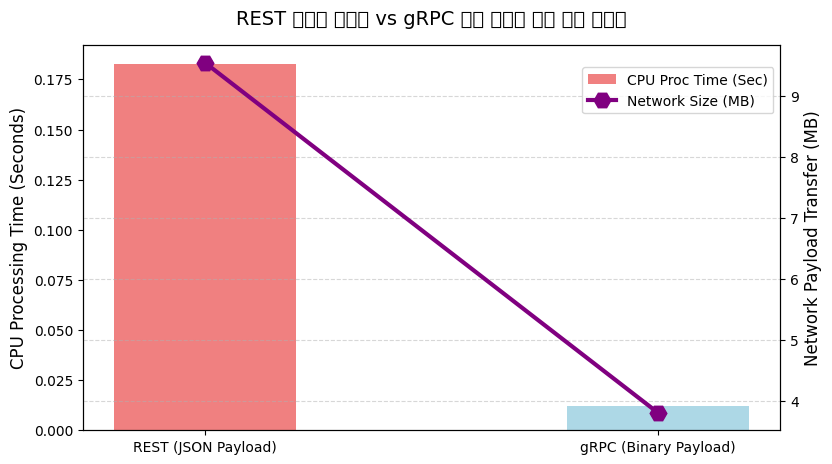

In [4]:
import json
import struct
import time
import matplotlib.pyplot as plt

num_elements = 1000000
data_list = [3.141592] * num_elements

# 시나리오 A: REST API망의 JSON 텍스트 파싱 전송 모사
start_time = time.time()
json_payload = json.dumps({"tensor": data_list})
json_time = time.time() - start_time
json_size_mb = len(json_payload.encode('utf-8')) / (1024 * 1024)

# 시나리오 B: gRPC망의 순수 이진 바이트(Byte) 압축 모사
start_time = time.time()
binary_payload = struct.pack(f'{num_elements}f', *data_list)
binary_time = time.time() - start_time
binary_size_mb = len(binary_payload) / (1024 * 1024)

print(f"✅ 일반적인 JSON(REST) 오버헤드 -> 걸린 시간: {json_time:.4f}초 / 통신 용량: {json_size_mb:.2f} MB")
print(f"✅ 구글의 Binary(gRPC) 최적화 -> 걸린 시간: {binary_time:.4f}초 / 통신 용량: {binary_size_mb:.2f} MB")

# ================= 결과 시각화 구성 =================
labels = ['REST (JSON Payload)', 'gRPC (Binary Payload)']
times = [json_time, binary_time]
sizes = [json_size_mb, binary_size_mb]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.bar(labels, times, color=['lightcoral', 'lightblue'], width=0.4, label='CPU Proc Time (Sec)')
ax2.plot(labels, sizes, color='purple', marker='H', linewidth=3, markersize=12, label='Network Size (MB)')

ax1.set_ylabel('CPU Processing Time (Seconds)', fontsize=12)
ax2.set_ylabel('Network Payload Transfer (MB)', fontsize=12)
plt.title("REST 텍스트 인코딩 vs gRPC 이진 인코딩 성능 차이 시각화", fontsize=14, pad=15)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.85))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



---


## 2. 부하 분산(Load Balancing): 길목 교통경찰의 진화 (L4와 L7)


기초 개념에서 배운 트래픽 분배 장비(교통경찰)가 과연 "패킷(상자)"을 얼마나 꼼꼼하게 검사하고 나누어 주느냐에 따라 L4 계층 모델과 L7 계층 모델로 나뉘게 됩니다.

### 2.1 L4 기반 부하 분산 (네트워크 IP 계층 밸런서)
건물 우편 번호(IP 주소와 TCP 포트 번호) 껍데기만 보고 기계적으로 트래픽을 던져버리는 분배 방식입니다.
- **핵심 장점**: 트래픽의 택배 상자 안쪽(우리가 보낸 HTTP 글자들)을 아예 까서 열어보지 않기 때문에 소모되는 연산력이 매우 낮고 빛의 속도로 초고속 처리가 가능합니다. 트래픽 인바운드 방어가 가장 강고하고 밀도가 높은 구조입니다.
- **치명적 단점**: 안을 열어보기 전이므로 이 요청이 "유저 정보(User API)"로 가야 할지 "결제 정보(Payment API)"로 가야 할지를 분류해 줄 지능이 없습니다. 단순 분배만 해댑니다.

### 2.2 L7 기반 부하 분산 (애플리케이션 HTTP 계층 밸런서)
고객이 들고 온 우편물 상자의 테이프를 강제로 뜯어, 그 안에 적힌 편지 내용물(HTTP Header 문자열, URL 도메인 경로 문자열 패턴 등)을 눈으로 꼼꼼히 모두 스캔한 뒤에 완벽한 목적지를 찾아 지능적 배차를 해주는 기술입니다.
- **SSL 오프로딩 (HTTPS 껍질 제거)**: 모든 보안 복호화 통제를 제일 앞 최전선의 밸런서 장비에게 전담시켜서 내부 개발자 서버들은 통신 연산 부하 없이 프로그래밍 로직 연산에만 100% 매달리게 만듭니다.
- **경로 기반 스마트 라우팅 분기**: `/api/vision` 문자가 포함되어 있으면 GPU 전용 서버군(Cluster)에만 할당해주고, `/api/nlp` 텍스트를 감지하면 자연어 처리 전담 서버로 격리 넘겨 줍니다.

### 2.3 gRPC 프로토콜에 L7 밸런서 장비가 꼭 필요한 사유 (핀 포인트 딜레마)
기초 부분에서 설명된 'gRPC 통신망'의 맨 앞에다가 멍청한 L4 로드밸런서를 붙이게 될 경우, 시스템 분산이 대 붕괴 해버리는 딜레마가 찾아옵니다.
gRPC는 단 1개의 연결 파이프(Session Connection)만 묵묵하게 열어두고 수만 건의 데이터를 쪼개어 실어 나르는 구조입니다. L4 밸런서는 "아하 연결이 1번 서버 1대하고만 하나 뚫렸구나!" 라고 무신경하게 고착화해 버립니다. 이후의 수십 만 클릭 트래픽이 1개 파이프를 타고 단 1대의 서버로만 몰빵 처리되어 버리는 무분산 병목이 찾아옵니다.
결국 이 연결 내의 프레임을 잘개 쪼개어서 검수하는 **'지능형 L7 Application 로드 밸런서 엔진'** 체벌이 마이크로서비스 MSA 설계에 강박관념적 필수 권장 사항입니다.



### 🔹 L4 vs L7 라우팅 분기 판단력 비교 흐름도


```mermaid
graph TD
    User([클라이언트 단 HTTP 트래픽]) --> LB{앞단의 관제탑 로드 밸런서 진입}
    
    subgraph "L4 계층: Network Load Balancer (TCP/UDP 하드웨어 급 오프로드)"
        LB -- "MAC, 포트, 출발지 및 시스템 IP 주소 스캔만 룰<br/>(내용물 블라인딩 상태)" --> Hash[해싱 알고리즘 기반 TCP 연결 무작위 일방 할당 라우팅]
        Hash --> |Connection Slot 1| Node1[백엔드 머신 클러스터 A]
        Hash --> |Connection Slot 2| Node2[백엔드 머신 클러스터 B]
    end
    
    subgraph "L7 계층: Application Load Balancer (문자 스캔 엔진 통합 탑재망)"
        LB -- "HTTP 패킷 Deep Header Inspection 개박<br/>(경로명 파싱 분석 엔진 동작)" --> Parser[URL 경로 스트링 분기 엔진 파싱 라우터]
        Parser -- "[/api/vision] 문자 감지 조건" --> TG_Vision[비전 영상 타겟 서버단 머신 셋업 풀]
        Parser -- "[/api/nlp] 문자 감지 조건" --> TG_NLP[텍스트 자연어 추론 타겟 서버단 머신 셋업 풀]
    end
```


### 👨‍💻 [연습 시뮬레이션] 로드 밸런서 계층별 내부 로직 프로세싱 모사


L4(단순 무작위 분배) 환경과 L7(문자 디코딩을 통한 타겟 배차) 환경이 실제 프로그래밍과 알고리즘 단위에서 어떻게 차이가 극명하게 발생되는지 파이썬 객체 지향 구조 모사 코드로 재현 동작합니다.


In [5]:
class L4_NetworkLoadBalancerCore:
    def __init__(self, backend_ips):
        self.backends = backend_ips
        self.req_count = 0

    def route(self, tcp_packet_bytes):
        # 4L 네트워크 특성: 들어온 패킷 내부를 열람해 볼 권한이 아예 없음 (블라인드 라우팅 모델링). 숫자 카운터로 때움
        target_ip = self.backends[self.req_count % len(self.backends)]
        self.req_count += 1
        return f"[L4 기계적 스위칭] TCP Payload 내부 열람 불가 보안 -> 무조건적 기계 IP {target_ip} 전송 발사!!"

class L7_ApplicationLoadBalancerCore:
    def __init__(self, target_groups):
        self.target_groups = target_groups

    def route(self, http_request_string):
        # 7L 애플리케이션 특성: HTTPS 암호화를 강제 복호화 한 후 URL 문자 구문(String Pattern) 내용기반 파싱을 개시함
        try:
            target_str_line = http_request_string.split('\n')[0]
            _, url_path, _ = target_str_line.split(' ')
            
            # Context-Path 기반 라우팅 제어 분기점
            if '/vision' in url_path:
                target_server = self.target_groups['vision_gpu_pool']
            elif '/nlp' in url_path:
                target_server = self.target_groups['nlp_tpu_pool']
            else:
                target_server = self.target_groups['default_web_pool']
                
            return f"[L7 스마트 정밀 라우팅] URI '{url_path}' 세부 내용 감지 완료 -> 전용 특화 클러스터 타겟 [{target_server}] 지정 배차"
        except Exception:
            return "[L7 Error Rule] 비정상 HTTP 침투 체계 강제 종단 차단"

# 로드밸런서 인프라 노드 엔진 코어 셋업 모델링
l4_lb_engine = L4_NetworkLoadBalancerCore(['10.0.1.10 (무작위 Node A)', '10.0.1.20 (무작위 Node B)'])
l7_lb_engine = L7_ApplicationLoadBalancerCore({
    'vision_gpu_pool': '10.0.2.100 (Vision Analysis 전용 머신망 그룹)',
    'nlp_tpu_pool': '10.0.2.200 (NLP 처리 메인 TPU 군 그룹)',
    'default_web_pool': '10.0.3.50 (기본 유저 데이터 웹API 반)'
})

# 가상 유저들의 요청 인입 패킷 흐름
req_vision = "POST /api/vision HTTP/1.1\nHost: cloud.com\n\n{\"image_feature\": \"0x0Fa...\"}"
req_nlp = "GET /api/nlp?infer_rule=AI_Prompt HTTP/1.1\nHost: cloud.com\n\n"

print("🔥 L4 밸런서의 안대 가린 배차 규칙 (Round Robin) 테스트 결과 🔥")
print(l4_lb_engine.route(req_vision))
print(l4_lb_engine.route(req_nlp))
print("\n💡 L7 밸런서의 시력 확인 문맥 배차 규칙 (Context Parsing) 테스트 결과 💡")
print(l7_lb_engine.route(req_vision))
print(l7_lb_engine.route(req_nlp))



🔥 L4 밸런서의 안대 가린 배차 규칙 (Round Robin) 테스트 결과 🔥
[L4 기계적 스위칭] TCP Payload 내부 열람 불가 보안 -> 무조건적 기계 IP 10.0.1.10 (무작위 Node A) 전송 발사!!
[L4 기계적 스위칭] TCP Payload 내부 열람 불가 보안 -> 무조건적 기계 IP 10.0.1.20 (무작위 Node B) 전송 발사!!

💡 L7 밸런서의 시력 확인 문맥 배차 규칙 (Context Parsing) 테스트 결과 💡
[L7 스마트 정밀 라우팅] URI '/api/vision' 세부 내용 감지 완료 -> 전용 특화 클러스터 타겟 [10.0.2.100 (Vision Analysis 전용 머신망 그룹)] 지정 배차
[L7 스마트 정밀 라우팅] URI '/api/nlp?infer_rule=AI_Prompt' 세부 내용 감지 완료 -> 전용 특화 클러스터 타겟 [10.0.2.200 (NLP 처리 메인 TPU 군 그룹)] 지정 배차


---


## 3. 강력한 네트워크 보안의 최후의 보루: 격리 망 아키텍처 이론 (VPC & Subnet)


마지막으로 0강 기초에서 배웠던 '울타리를 친 사유성 네트워크', 즉 VPC 망 모델의 내부 격리 방어를 파헤쳐 봅니다.

### 3.1 위험 외부 개방 지대 (Public Subnet)와 절단된 보안 금고 (Private Subnet)의 단차
거대하게 할당받은 나만의 인프라 IP 공간(예: 6만 개의 방)을 다시 반 토막 분할 제어하여 안전한 요새 라인으로 셋업합니다. 인터넷 망 접속 차단 룰이 어떻게 그곳에 스코핑 매칭되느냐에 따라 나뉘어집니다.

- **Public Subnet (DMZ 지대)**: 외부 인터네망으로 직결되는 인터넷 게이트웨이 파이프라인이 살아 숨쉬는 거실 같은 공간입니다. 공용 IP 주소 인가받고 여기서 머신을 켜면 세계 어디 모바일 폰에서도 Ping이 도달하여 통신이 뚫립니다. 너무나도 끔찍하게 자산이 공격받기 좋은 위협 지대이므로 비즈니스 핵심 로직 코어 애플리케이션은 여기에 두지 말고 단지 **L7 로드 밸런서 방화벽(ALB)** 만을 최소한의 문지기로 남겨 둡니다.
- **Private Subnet (격리 심연 금고 지대)**: 인터넷 게이트웨이 파이프라인 케이블 배선 자체가 라우팅 인프라서 싹둑 절단되어 폐쇄된 망입니다. IP 자산 주소를 달고 있더라도 공인 인터넷을 경유하고 해커가 침입 도청할 핑 주소 길 찾기 자체가 프로토콜 물리 계층적으로 불가능(Unreachable) 방벽 구성되어 원천 접근 차단이 단절 보장되어 있습니다. 이 철벽 보안이 있어야만 파이프라인 깊숙한 곳 메인 **유저 프라이빗 DB (RDBMS), 고비용 빅데이터 모델 학습 GPU 노드 엔진 인프라 클러스터 서빙 서버망** 등의 본사가 무탈하게 안전 가동 생존 존속될 수 있습니다.

### 3.2 아웃바운드 업데이트 통신 확보의 한계와 NAT(Network Address Translation) 단방향 솔루션
Private 망에 비싼 AI GPU 서버가 봉인되어 있다는 건 완벽하게 도둑을 막는다는 얘기지만, 치명적 딜레마를 생산합니다. 인공지능 개발 파트가 최신 AI 라이브러리를 인스톨 및 업데이트하거나 외부 저장소에서 수 십 기가바이트 텐서 모델들을 `Pull 다운로드` 받으려면 컴퓨터 내부 통신망에서 인터넷 세계로 나가는 길문(**아웃바운드**)이 오픈 활착 되어야 하는데 고립된 상태이기 때문에 커맨드 창이 무력화되어 아무 반응이 뜨지 않기 때문입니다.

이 고립 딜레마를 마법 같이 타파하는 방어 통신 인프라 우회 기법이 바로 **NAT Gateway 시스템 인프라 구축 매커니즘** 입니다.
1. 지상망인 오픈 Public 환경 티어 구간 접경에 값 비싼 트래픽 제어 대리인 장비인 NAT 기기를 구축해 둡니다.
2. 지하망의 코어 모델 인스턴스 서버들이 외부 인터넷 요청을 날리면 본인 스스로 나가지 않고 백본선 캡슐링을 타고 지상 구간의 NAT 수문장에게 짐과 함께 대신 부탁해 패킷을 위로 던집니다.
3. 요청을 대신 넘겨받은 공용망 인가 IP의 NAT 기계는 사설IP 지문을 싹 폐기 감추어버리고 **본인의 떳떳한 공용 독자 IP인 것처럼 세탁 변환(IP Translation) 포장** 처리하여 외부 인터넷망 원격 스토어를 다녀온 뒤, 데이터를 건져내면 내부 연혁 장부를 테이블 대조 조회해 본래 요청을 했던 지하망의 장비로 결과 리턴 값을 몰래 토스해 건네줍니다.
4. **절대적인 핵심 단방향성 철학**: '지하 내부 보안 서브넷 안에서 필요에 의해 직접 수급 시작을 촉발시킨 인터넷 아웃바운드 요청 시작'은 포트 오픈 허용 지원해주되, **반대로 외부 인터넷의 불량 공략 서버 측에서 우리가 Public 영역에 가동시켜 둔 NAT 수문장 장비를 통해 어떻게 터널링 해킹을 하여 지하 Private망 데이터베이스 존으로 진입(Inbound) 도킹 하는 해킹 시나리오는 네트워크 프로토콜 하드웨어적 설계 규약 방벽 상 원천 봉쇄되는 단방향 통과** 설계 디자인입니다.



### 🔹 전사 프라이빗 클라우드 아키텍처 방어 플로우 모델 도해


```mermaid
graph TB
    Internet([대외 거대 인터넷 공용 클라우드 전조망 환경])
    
    subgraph VPC [인프라스트럭처의 견고한 척추 망: 사설 VPC 내부 물리 망 구조]
        IGW[Internet Gateway 외부 차단 관제 선단]
        
        subgraph PublicSubnet [Public 방패 Subnet 노출 거실 구역 (DMZ Zone)]
            ALB[L7 Application 로드 밸런서 기반 방화 인가 오프로드 판넬]
            NAT[NAT Gateway 단방향 아웃바운드 라우팅 프록시 서버망]
        end
        
        subgraph PrivateSubnet [Private Subnet 접근 원천 불가 폐쇄 에어갭 유사망 격리 구역]
            WebAPI[Backend 인증 및 코어 API 비즈니스 로직 클러스터]
            GPU1[대규모 GPU/NPU Inference 머신러닝 Worker Node 머신 A]
            GPU2[대규모 GPU/NPU Inference 머신러닝 Worker Node 머신 B]
            DB[(고객 결제 메인 마스터 DB 원장 & AI Vector 텐서 스토리지 저장망)]
        end
    end

    Internet -->|DDoS 침투 선별 및 다수 클라이언트 정상 트래픽 접속 등단 인바운드 단 유입| IGW
    IGW -->|오로지 L7 ALB 전면 관제망 포트만 유일 진입 노출 포워딩 라우드 수락| ALB
    ALB -->|인증 필터 텍스트 문구 등 스마트 검열을 하사 받은 깨끗한 트래픽만 내부 코어로 유도| WebAPI
    WebAPI -->|JSON 병목 타파용 gRPC 패키징 통일 압축 Protobuf 활용의 마이크로서비스 내부 병렬 고속 통신 가동| GPU1 & GPU2
    GPU1 & GPU2 -->|결과물 및 SQL 로킹 등 상태 관리 저장 통제 DB 동기화 연산 백 채널 운용| DB
    
    GPU1 -.->|주기적으로 S3 데이터 등 무거운 AI 모델 가중치(Heavy Weights Model) 다운로드 Fetch 커맨드 필요 시 발동| NAT
    NAT -.->|요청 송신처 사설 내부망 IP 주소를 공용 주소로 세탁 대리 후 바깥 외해망 방출 오픈 호출 수행| IGW
    IGW -.->|원격 스토리지 통신 규약 성공 검증 시 결과 데이터 바이트 블록 수집 후 회선 단방향 반납 귀환 응답| NAT
```
